In [90]:
# Load packages and dataset.
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [73]:
# Load the iris dataset as a bunch object, which is like a dictionary, with keys and attributes.
iris = load_iris(as_frame=True)
print(iris.keys())

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


In [74]:
# Look inside the data to determine how to format for pandas.
# The data I need is inside the "frame" key.
for key in iris.keys():
    print("The contents of the '{}' key are:".format(key))
    print(iris[key])

The contents of the 'data' key are:
     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                  5.1               3.5                1.4               0.2
1                  4.9               3.0                1.4               0.2
2                  4.7               3.2                1.3               0.2
3                  4.6               3.1                1.5               0.2
4                  5.0               3.6                1.4               0.2
..                 ...               ...                ...               ...
145                6.7               3.0                5.2               2.3
146                6.3               2.5                5.0               1.9
147                6.5               3.0                5.2               2.0
148                6.2               3.4                5.4               2.3
149                5.9               3.0                5.1               1.8

[150 rows x 4 columns]
The 

In [75]:
# Load the "frame" data as a dataframe.
df = iris["frame"]
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [76]:
# Create an additional column of target names using a dictionary mapping class numbers to class names, and add this column to the end.
target_name_dict = {0: "Setosa", 1: "Versicolor", 2: "Virginica"}
target_names = df["target"].replace(target_name_dict)
print(target_names)
df["target names"] = target_names

0         Setosa
1         Setosa
2         Setosa
3         Setosa
4         Setosa
         ...    
145    Virginica
146    Virginica
147    Virginica
148    Virginica
149    Virginica
Name: target, Length: 150, dtype: object


In [77]:
# The new dataframe with added columns.
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target names
0,5.1,3.5,1.4,0.2,0,Setosa
1,4.9,3.0,1.4,0.2,0,Setosa
2,4.7,3.2,1.3,0.2,0,Setosa
3,4.6,3.1,1.5,0.2,0,Setosa
4,5.0,3.6,1.4,0.2,0,Setosa
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2,Virginica
146,6.3,2.5,5.0,1.9,2,Virginica
147,6.5,3.0,5.2,2.0,2,Virginica
148,6.2,3.4,5.4,2.3,2,Virginica


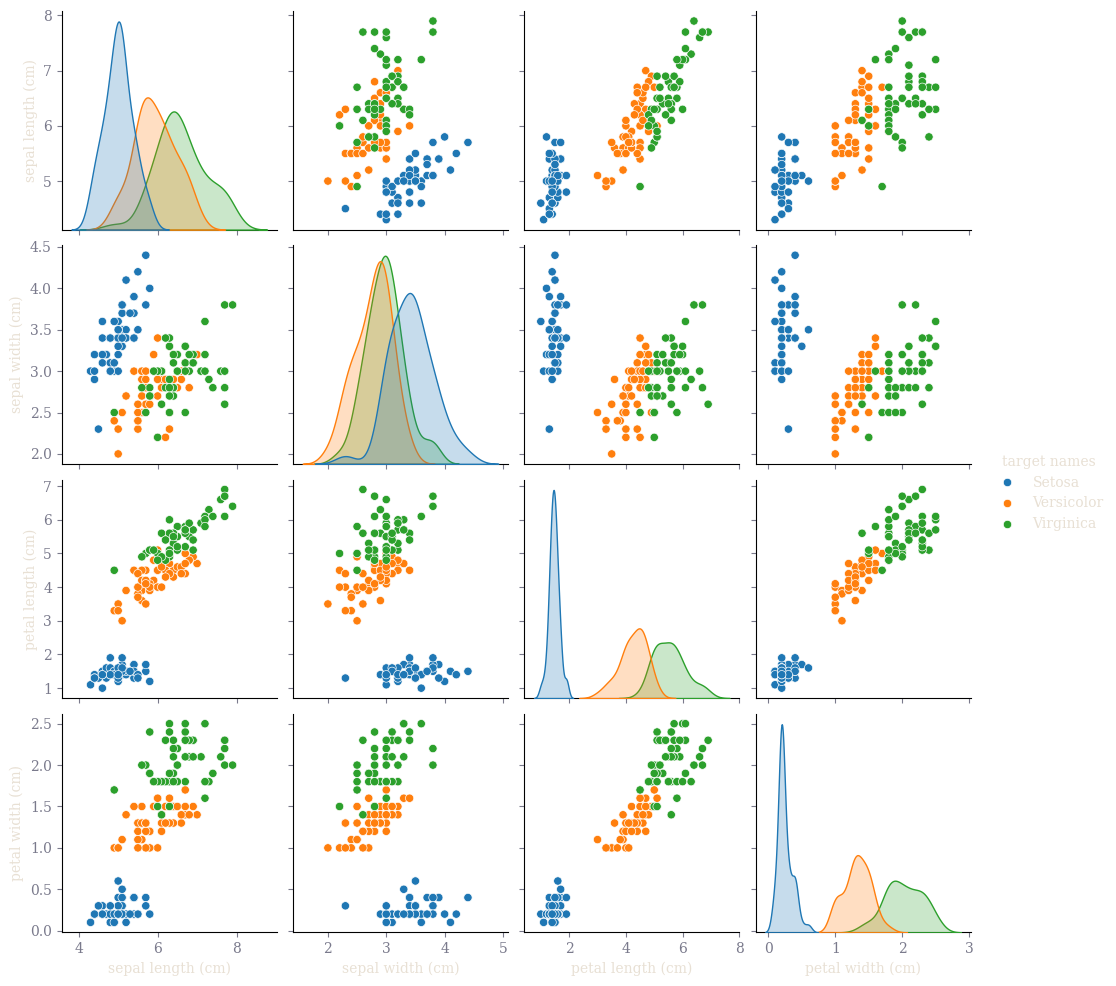

In [ ]:
# Now visualise a pairs-plot, which plots data columns in pairs as scatter plots.
# To do this, remove the "target" class label column, otherwise these will be included in scatter plots.
pairs_df = df.drop("target", axis="columns")
_ = sns.pairplot(pairs_df, hue="target names")

* The diagonal plots here are kernel density estimates, akin to continuous plots of the probability density of the random variable in question.
    * Some clustering across classes in sepal length, going from lowest setosa, to versicolor, virginica highest.
    * Much more clustering across classes in sepal width, and all quite similar.
    * Petal measurements much more distinctly clustered than sepal measurements.
    * Very pronounced clustering across petal length, going from lowest setosal, to versicolor, viriginica highest.
    * Most pronounced clustering across petal width, going from lowest setosa, to versicolor, virginica highest. 
    * Kernel density estimates suggest,
        * Setosa - Very short petal widths and lengths, sepal lengths, and highest sepal width.
        * Versicolor - Average measurements across the board, lowest sepal width
        * Virginica - High petal widths, lengths, sepal lengths, average sepal width.
    * PCA will be looking at directions of greatest variance - can you identify which ones are going to be selected?
        * Not before standardisation.
* The off-diagonal plots are bivariate scatter plots
* Continue analysis tomorrow.

PCA - pre-processing.

- Theoretical accounts of PCA, both at the population level and at the sample level mandate mean-centering as an essential step in pre-processing. - why?
- But the case for standardisation in pre-processing, i.e. dividing by the standard deviation, or its sample estimate, is a matter of data analysis.
- If we are working with features with different measurements e.g. sepal lengths and also mineral uptake efficiency, then standardisation is required to homogenise variations in measurement magnitudes for comparison.
- As we are dealing with uniform measurements in centimetres, we decide to mean center but not scale the data by dividing by the standard deviation.

To anchor this in the theory at population level, we have a $d$-dimensional random vector $Y \in \mathbb{R}^d$ with mean $\mu_Y$. For PCA, we instead work with the mean-centred random vector $X \in \mathbb{R}^d$, where $X = Y - \mu_Y$, so that the mean of $X$ is $\mu = 0$, and its variance-covariance matrix is $\boldsymbol{\Sigma} = \text{Cov}(X) = \mathbb{E}[XX^{\top}]$.

Our iris-data consists of an observation matrix $\boldsymbol{Y} \in \mathbb{R}^{n \times d}$ with $n = 150$ observations and $d = 4$ features, 

Data Leakage Warning (DLW)

- Although we are carrying out dimensionality reduction, we will not be using transformed as an input into a supervised learning model.
- If we were to do so, then carrying out PCA on the entire dataset without first splitting it into a training-test set would mean that information from the test-set would "leak" into the training phase.
- In this case, we would carry out our PCA pre-processing on the training data only, then use the same transform on the test-set data.

In [79]:
# Implement mean-subtraction using pandas inline functions.
# Compute the mean of each column, dropping the "target names" column as non-numeric, and dropping the "target" column containing flower class numbers.
df_numeric = df.select_dtypes(include=["number"])
df_numeric = df_numeric.iloc[:, 0:4]
df_numeric.mean()

sepal length (cm)    5.843333
sepal width (cm)     3.057333
petal length (cm)    3.758000
petal width (cm)     1.199333
dtype: float64

In [80]:
# Now implement mean-subtraction.
df_numeric - df_numeric.mean()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-0.743333,0.442667,-2.358,-0.999333
1,-0.943333,-0.057333,-2.358,-0.999333
2,-1.143333,0.142667,-2.458,-0.999333
3,-1.243333,0.042667,-2.258,-0.999333
4,-0.843333,0.542667,-2.358,-0.999333
...,...,...,...,...
145,0.856667,-0.057333,1.442,1.100667
146,0.456667,-0.557333,1.242,0.700667
147,0.656667,-0.057333,1.442,0.800667
148,0.356667,0.342667,1.642,1.100667


In [81]:
# Now use sklearn preprocessing using sklearn.preprocessing.StandardScaler.
# Remember we set `with_std=False` kwarg because we do not want scaling, only centering.
scaler = StandardScaler(with_mean=True, with_std=False)
scaler = scaler.set_output(transform="pandas")
X = scaler.fit_transform(df_numeric)
X

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-0.743333,0.442667,-2.358,-0.999333
1,-0.943333,-0.057333,-2.358,-0.999333
2,-1.143333,0.142667,-2.458,-0.999333
3,-1.243333,0.042667,-2.258,-0.999333
4,-0.843333,0.542667,-2.358,-0.999333
...,...,...,...,...
145,0.856667,-0.057333,1.442,1.100667
146,0.456667,-0.557333,1.242,0.700667
147,0.656667,-0.057333,1.442,0.800667
148,0.356667,0.342667,1.642,1.100667


Running PCA - choosing the number of components.

* Remember from 5 years ago that scikit-learn is very user friendly in terms of its syntax.
* You initialise the relevant ML algorithm class object with the relevant ML algo parameters, then call the various methods.
* The number of principal components $k$ is the dimension of the subspace $U$ we wish to project onto.
* It can be viewed as a hyperparameter that is:
    * Chosen by means of an exploratory scree-plot with a heuristic "cut-off" for the proportion of variance explained by each principal component.
    * Tuned via cross-validation, typically used when using PCA to dimensionally reduce data for use in a downstream ML task in a pipeline e.g. as input to a neural network.
    * Selected via automatic algorithmic methods.

* Data Leakage Warning: Don't ever call `.fit()` or `.fit_transform()` on test data!
    - Context of this DLW is if we are using PCA dimensionality as part of a broader ML pipeline.
    - If we are splitting the data into training data and testing data, then we use training data for:
        - PCA preprocessing like scaling/centering.
        - Extracting orthonormal bases.
        - Reduce the dimensionality of the data by projecting using orthonormal bases to train the supervised learning algorithm.
    - During testing phase, when we test our ML pipeline, then we can only do the following using test data:
        - PCA preprocess the test data e.g. centering and scaling using only estimates from training.
        - Reduce the dimensionality of the test data by projecting using orthonormal bases learned during training.

In [82]:
# Now run PCA with the number of components equal to the number of dimensions.
# Will call `.fit()`, so that I can access the explained variance ratio of each principal component.
# We can plot this in a scree plot to determine how many principal components to actually use.

pca_full = PCA(n_components=4).set_output(transform="pandas")
pca_full.fit(X)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",4
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD 

In [83]:
# Tabulate the explained variance ratio of all principal components.

scree_df = pd.DataFrame({"Principal component": [f"PC{i+1}" for i in range(4)],
                         "Explained variance ratio": pca_full.explained_variance_ratio_,
                         "Cumulative explained variance ratio": [np.sum(pca_full.explained_variance_ratio_[:i+1]) for i in range(4)]})
scree_df

,Principal component,Explained variance ratio,Cumulative explained variance ratio
0,PC1,0.924619,0.924619
1,PC2,0.053066,0.977685
2,PC3,0.017103,0.994788
3,PC4,0.005212,1.000000


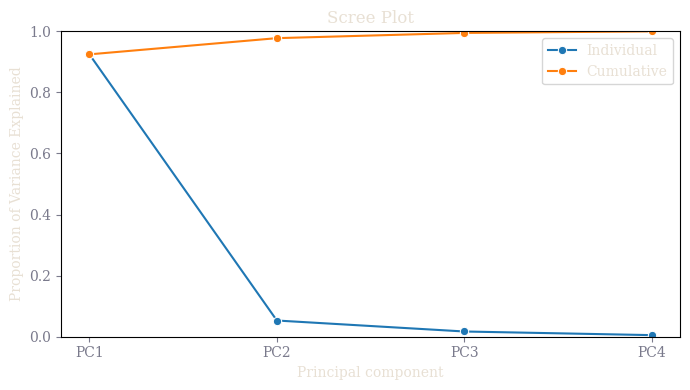

In [84]:
# Show this as a scree plot.

fig, ax = plt.subplots(figsize=(7,4))
sns.lineplot(data=scree_df, x="Principal component", y="Explained variance ratio",
             marker="o", label="Individual", ax=ax)
sns.lineplot(data=scree_df, x="Principal component", y="Cumulative explained variance ratio",
             marker="o", label="Cumulative", ax=ax)
ax.set_title("Scree Plot")
ax.set_ylabel("Proportion of Variance Explained")
ax.set_ylim(0,1)
plt.tight_layout()
plt.show()

Running PCA - projecting the data.

- Our scree plot shows that the first two principal components explain 97% of the total variance of the data.
- 

In [86]:
# `.components_` shows each orthonormal basis vector as a row of matrix.
# We rewrite it so that the orthonormal basis matrix has each subspace basis vector as a column.
# V is the orthonormal matrix of the eigenvectors of the sample covariance matrix S.
basis_output = pca.components_
V = basis_output.T
print(V)

[[ 0.36138659  0.65658877 -0.58202985  0.31548719]
 [-0.08452251  0.73016143  0.59791083 -0.3197231 ]
 [ 0.85667061 -0.17337266  0.07623608 -0.47983899]
 [ 0.3582892  -0.07548102  0.54583143  0.75365743]]


In [87]:
# `.fit_transform() computes the dimensionally reduced projected data, in subspace coordinates.

proj_X = pca.fit_transform(X)
proj_X

,pca0,pca1,pca2,pca3
0,-2.684126,0.319397,-0.027915,0.002262
1,-2.714142,-0.177001,-0.210464,0.099027
2,-2.888991,-0.144949,0.017900,0.019968
3,-2.745343,-0.318299,0.031559,-0.075576
4,-2.728717,0.326755,0.090079,-0.061259
...,...,...,...,...
145,1.944110,0.187532,0.177825,0.426196
146,1.527167,-0.375317,-0.121898,0.254367
147,1.764346,0.078859,0.130482,0.137001
148,1.900942,0.116628,0.723252,0.044595


In [88]:
# `.inverse_transform(proj_X)` computes a reconstruction of the projected data in the original space vector space coordinates.
reconstr_X = pca.inverse_transform(proj_X)
reconstr_X = pd.DataFrame(data=reconstr_X, columns=X.columns)
reconstr_X

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-0.743333,0.442667,-2.358,-0.999333
1,-0.943333,-0.057333,-2.358,-0.999333
2,-1.143333,0.142667,-2.458,-0.999333
3,-1.243333,0.042667,-2.258,-0.999333
4,-0.843333,0.542667,-2.358,-0.999333
...,...,...,...,...
145,0.856667,-0.057333,1.442,1.100667
146,0.456667,-0.557333,1.242,0.700667
147,0.656667,-0.057333,1.442,0.800667
148,0.356667,0.342667,1.642,1.100667
